In [80]:
import pdb
import glob
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
%matplotlib inline

import inversion_tools

pdir  = '/work/noaa/co2/jhollo/processed_transport_data/'
ddir  = '/home/jhollo/wombat_stuff_link/wombat-v3-forward/4a_postprocessing_gc/intermediates/monthly-fluxes'

weighted_lat_avg = lambda data: data.weighted(np.cos(np.deg2rad(data.lat))).mean('lat')
lon_avg          = lambda data: data.mean('lon')
horz_avg         = lambda data: lon_avg(weighted_lat_avg(data))

pfts = [
    (1, "DBG", "Desert and Bare Ground"),
    (2, "ENF", "Evergreen Needleleaf Forest"),
    (3, "DNF", "Deciduous Needleleaf Forest"),
    (4, "EBF", "Evergreen Broadleaf Forest"),
    (5, "DBF", "Deciduous Broadleaf Forest"),
    (6, "SHB", "Shrubs (Non-Tundra)"),
    (7, "SHA", "Tundra Shrubs"),
    (8, "C3A", "Tundra Grassland"),
    (9, "C3G", "C3 Grassland"),
    (10, "C4G", "C4 Grassland"),
    (11, "C3C", "C3 Generic Crop"),
    (12, "C4C", "C4 Generic Crop"),
    (13, "MZE", "Maize"),
    (14, "SOY", "Soybeans"),
    (15, "WWT", "Winter Wheat"),
]

In [120]:
def get_gpp_intercept(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_intercept_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp
def get_gpp(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    resp_files = sorted(glob.glob(f'{ddir}/bio_resp_tot_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    resp = xr.concat([horz_avg(xr.open_dataset(f)['flux']) for f in resp_files], 'time')
    resp = resp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp
def get_gpp_latlon(region, pft):
    gpp_files = sorted(glob.glob(f'{ddir}/bio_gpp_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    resp_files = sorted(glob.glob(f'{ddir}/bio_resp_tot_residual_pft{pft:02d}_regionRegion{region:02d}*'))
    gpp = xr.concat([xr.open_dataset(f)['flux'] for f in gpp_files], 'time')
    gpp = gpp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    resp = xr.concat([xr.open_dataset(f)['flux'] for f in resp_files], 'time')
    resp = resp * 1000 * (24*60*60) #convert from kg m2/s to g m2/day
    return gpp

In [122]:
gpp = get_gpp_intercept(11, 9) # eu, C3 grasses
gpp

<xarray.DataArray 'flux' (time: 115)> Size: 920B
array([-0.03142006, -0.02690694, -0.02281359, -0.02044057, -0.02163302,
       -0.0252404 , -0.02961283, -0.03415601, -0.03813436, -0.04023741,
       -0.03924664, -0.03585866, -0.03145764, -0.02694648, -0.02284609,
       -0.02044697, -0.02160848, -0.02527361, -0.02972179, -0.03426368,
       -0.03821337, -0.04025361, -0.03919365, -0.03575628, -0.03134673,
       -0.02683657, -0.02275963, -0.02042836, -0.02167436, -0.02531211,
       -0.02968597, -0.03422206, -0.03818637, -0.04024847, -0.03921195,
       -0.03579357, -0.03138494, -0.02687197, -0.02278818, -0.02043477,
       -0.02165158, -0.02527212, -0.02965051, -0.03418768, -0.03815833,
       -0.04024484, -0.03922925, -0.03582645, -0.03142408, -0.02691278,
       -0.0228181 , -0.02044124, -0.02163007, -0.02523489, -0.02960803,
       -0.03415234, -0.03812945, -0.04023797, -0.03924964, -0.03586303,
       -0.03146505, -0.02695135, -0.02284857, -0.02044444, -0.02160867,
       -0.0252685 , -0.02971628, -0.03425511, -0.0382083 , -0.04025296,
       -0.03919571, -0.03576287, -0.03135061, -0.02684264, -0.02276216,
       -0.02043099, -0.02167334, -0.02530433, -0.02968082, -0.03421792,
       -0.0381835 , -0.04024886, -0.03921572, -0.03579901, -0.03138983,
       -0.02687597, -0.02279309, -0.02043498, -0.02164953, -0.02526603,
       -0.02964386, -0.03418136, -0.03815352, -0.04024417, -0.03923211,
       -0.03583111, -0.03143085, -0.02691925, -0.02282307, -0.02044022,
       -0.02162367, -0.02523079, -0.02960186, -0.03414706, -0.03812434,
       -0.04023915, -0.03925253, -0.03586906, -0.03147168, -0.02695645,
       -0.02285377, -0.02044487, -0.02160603, -0.02526169, -0.0297105 ])
Coordinates:
  * time     (time) datetime64[ns] 920B 2014-09-01 2014-10-01 ... 2024-03-01

(-0.025, 0.015)

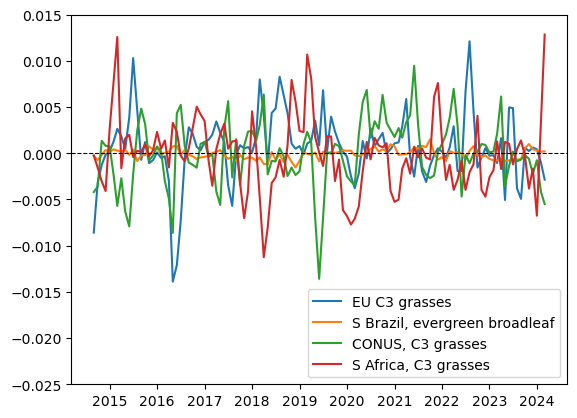

In [22]:
gpp = get_gpp(11, 9) # eu, C3 grasses
plt.plot(gpp.time, gpp, label='EU C3 grasses')
gpp = get_gpp(4, 4) # S brazil, evergreen broadleaf
plt.plot(gpp.time, gpp, label='S Brazil, evergreen broadleaf')
gpp = get_gpp(2, 9) # conus, C3 grasses
plt.plot(gpp.time, gpp, label='CONUS, C3 grasses')
gpp = get_gpp(6, 9) # S africa, C3 grasses
plt.plot(gpp.time, gpp, label='S Africa, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.legend(loc='lower right')
plt.ylim([-0.025, 0.015])

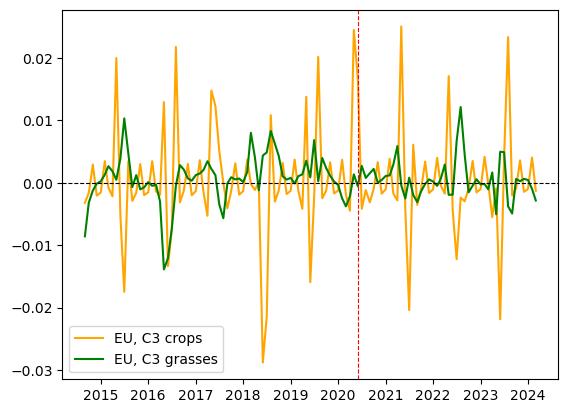

In [31]:
gpp = get_gpp(11, 11) # eu, C3 crops
plt.plot(gpp.time, gpp, 'orange', label='EU, C3 crops')
gpp = get_gpp(11, 9) # eu, C3 grasses
plt.plot(gpp.time, gpp, 'g', label='EU, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.axvline(x=np.datetime64("2020-06-03"), linestyle='--', color='r', linewidth=0.8)
plt.legend()

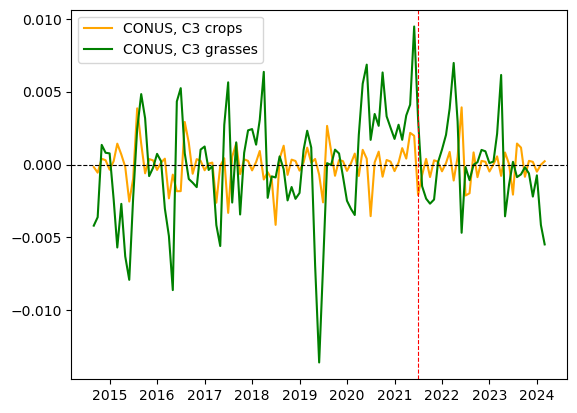

In [32]:
gpp = get_gpp(2, 11) # conus, C3 crops
plt.plot(gpp.time, gpp, 'orange', label='CONUS, C3 crops')
gpp = get_gpp(2, 9) # conus, C3 grasses
plt.plot(gpp.time, gpp, 'g', label='CONUS, C3 grasses')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.axvline(x=np.datetime64("2021-07-02"), linestyle='--', color='r', linewidth=0.8)
plt.legend()

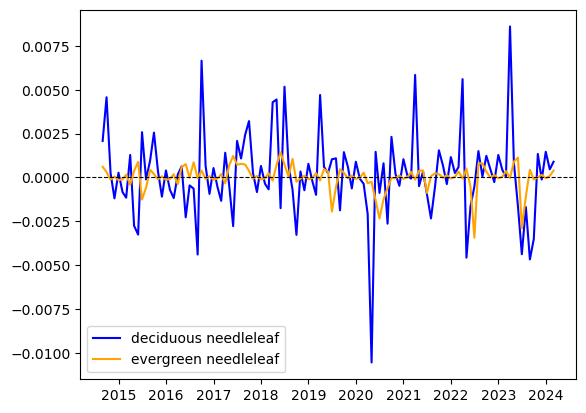

In [129]:
gpp = get_gpp(7, 2) 
plt.plot(gpp.time, gpp, 'b', label='deciduous needleleaf')
gpp = get_gpp(7, 3) 
plt.plot(gpp.time, gpp, 'orange', label='evergreen needleleaf')
plt.axhline(y=0, linestyle='--', color='k', linewidth=0.8)
plt.legend()

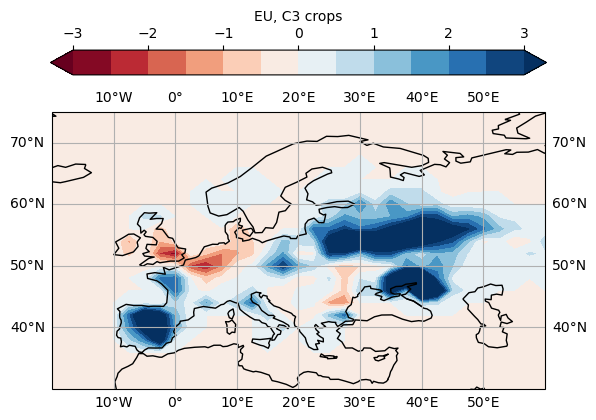

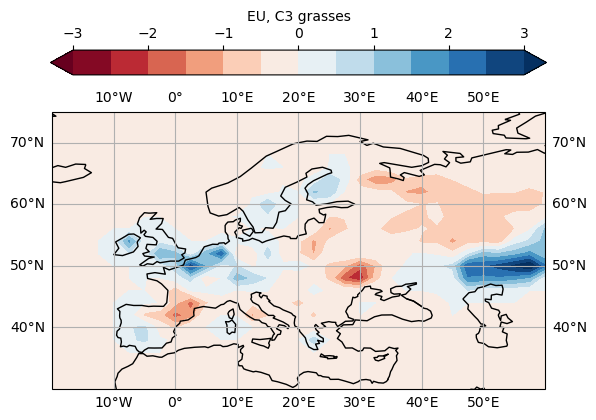

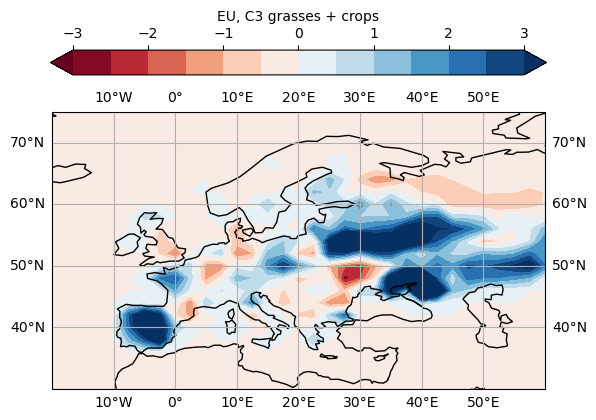

In [72]:
levels = np.arange(-3, 3.1, 0.5)

gpp = get_gpp_latlon(11, 11) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 crops', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

gpp = get_gpp_latlon(11, 9) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 grasses', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

gpp = get_gpp_latlon(11, 9) +  get_gpp_latlon(11, 11) # eu, all C3
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, C3 grasses + crops', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

In [82]:
levels = np.arange(-3, 3.1, 0.5)
bad_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(11, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(11, pft)
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=np.datetime64("2020-06-03"), method='nearest')

skipping pft 1
skipping pft 3
skipping pft 4
skipping pft 6
skipping pft 10
skipping pft 12
skipping pft 14


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


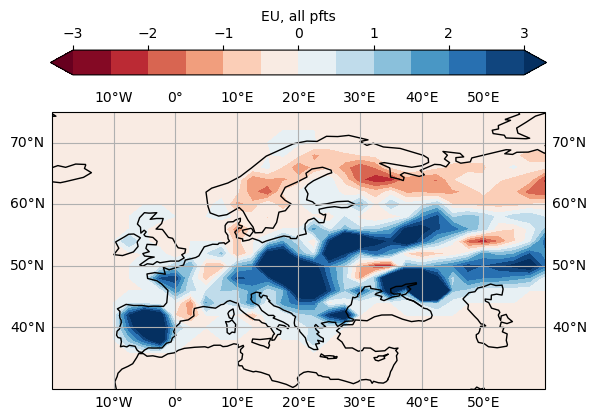

In [83]:
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, all pfts', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

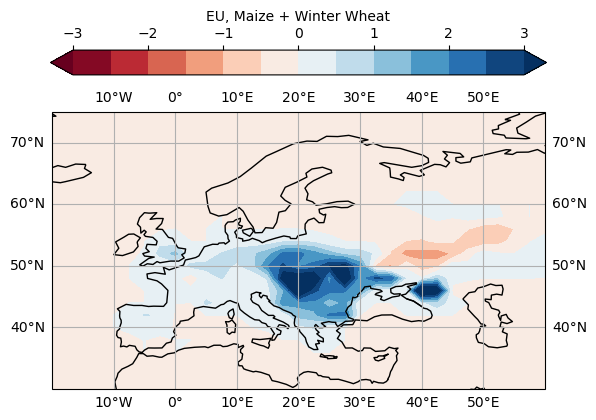

In [96]:
gpp = get_gpp_latlon(11, 13) + get_gpp_latlon(11, 15) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='EU, Maize + Winter Wheat', location='top', pad=0.1)
ax.set_extent([-20, 60, 30, 75], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)

In [84]:
levels = np.arange(-3, 3.1, 0.5)
bad_pfts = []

gpp_set = False
for pft in np.arange(1, 16, 1):
    try:
        if(not gpp_set):
            gpp_all_pft = get_gpp_latlon(2, pft)
            gpp_set = True
        else:
            gpp_all_pft += get_gpp_latlon(2, pft)
    except ValueError:
        print(f'skipping pft {pft}')
        bad_pfts.append(pft)
        continue
gpp_all_pft = gpp_all_pft.sel(time=np.datetime64("2021-07-02"), method='nearest')

skipping pft 1
skipping pft 3
skipping pft 4
skipping pft 7
skipping pft 8
skipping pft 12


,npft,clen,PFT
0,1,DBG,Desert and Bare Ground
1,2,ENF,Evergreen Needleleaf Forest
2,3,DNF,Deciduous Needleleaf Forest
3,4,EBF,Evergreen Broadleaf Forest
4,5,DBF,Deciduous Broadleaf Forest
5,6,SHB,Shrubs (Non-Tundra)
6,7,SHA,Tundra Shrubs
7,8,C3A,Tundra Grassland
8,9,C3G,C3 Grassland
9,10,C4G,C4 Grassland


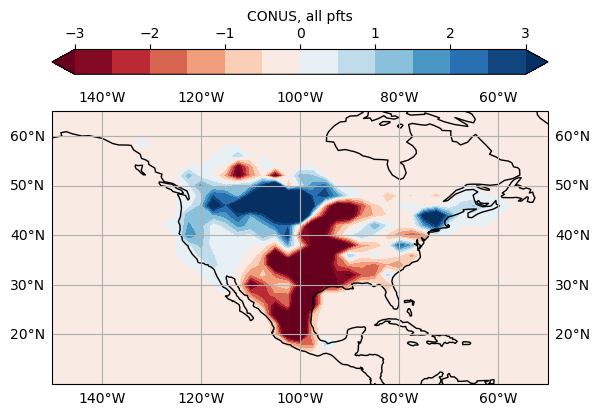

In [88]:
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp_all_pft.lon, gpp_all_pft.lat, gpp_all_pft, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='CONUS, all pfts', location='top', pad=0.1)
ax.set_extent([-150, -50, 10, 65], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)


df = pd.DataFrame(pfts, columns=["npft", "clen", "PFT"])
red_rows = bad_pfts
def highlight_red(row):
    return ["color: red" if row.npft in red_rows else "" for _ in row]
df.style.apply(highlight_red, axis=1)

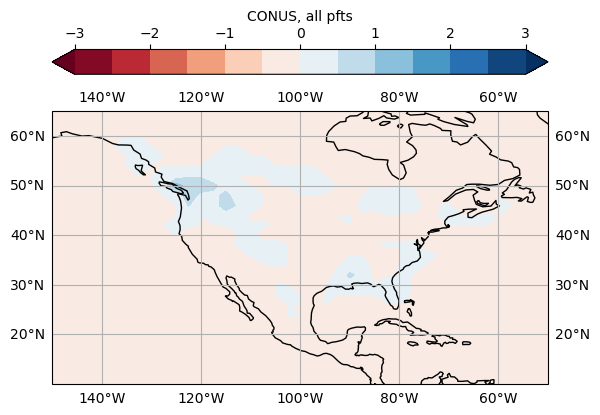

In [123]:
gpp = get_gpp_latlon(2, 2) # eu, C3 crops
gpp = gpp.sel(time=np.datetime64("2020-06-03"), method='nearest')
fig = plt.figure()
ax  = fig.add_subplot(projection=ccrs.PlateCarree())
cf  = ax.contourf(gpp.lon, gpp.lat, gpp, cmap='RdBu', levels=levels, extend='both')
cb  = fig.colorbar(cf, ax=ax, label='CONUS, all pfts', location='top', pad=0.1)
ax.set_extent([-150, -50, 10, 65], crs=ccrs.PlateCarree())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=True)